# Applying DeepRV to IPMs
In this notebook, we aim to use **DeepRV** to mimic realisations from a Gaussian process, and then apply this idea to Bayesian vital rate fitting in integral projection models (IPMs).

Let $(s \in \mathbb{R}^n)$ denote a fixed set of input points, and let $(k_{\theta}(\cdot,\cdot))$ be a kernel function with parameters $(\theta)$. We assume

$$
f(s) \sim \mathcal{GP}(0, K_{\theta}),
\qquad
(K_{\theta})_{ij} = k_{\theta}(s_i, s_j).
$$

Equivalently, a draw from the Gaussian process can be written as

$$
f(s) = L_{\theta} z,
\qquad
z \sim \mathcal{N}(0, I_n),
\qquad
L_{\theta} = \mathrm{chol}(K_{\theta}).
$$

Since the Cholesky decomposition of an $(n \times n)$ matrix scales as $(O(n^3))$, we hope to train a neural network that provides a faster approximation:

$$
\mathrm{DeepRV}(\theta, z) \approx f(s).
$$

In the IPM setting, the fixed input points are naturally the observed sizes in the life-cycle table. However, since we also need vital rates evaluated at the mesh points, we include both observed sizes and mesh points in the input vector:

$$
s' = [s, m]^{\top}.
$$

For the survival model, the hierarchy is

$$
\theta \sim p(\theta),
$$

$$
f(s') \mid \theta \sim \mathcal{GP}(0, K_{\theta})

$$

$$
y \sim \mathrm{Bernoulli}\left(\sigma\left(f(s')\right)\right),
$$

where $\sigma(\cdot)$ is the logistic sigmoid function. Note that there are no observations for the mesh points.

The target posterior is therefore

$$
p(\theta, f \mid y)
\propto
p(\theta), p(f \mid \theta), p(y \mid f, \theta).
$$

During inference, we draw samples from this posterior using HMC. At each iteration of HMC, given the current state $(\theta, f)$, we must evaluate the log posterior:

$$
\log p(\theta, f \mid y)
=

\log p(\theta)
+
\log p(f \mid \theta)
+
\log p(y \mid f, \theta).
$$

Since f depends on the Gaussian process draw, computing it directly requires the Cholesky decomposition, which is expensive. DeepRV is intended to replace this costly step with a faster neural network approximation.

We use simulated data from IBM simulations as ground truth labels. The data was simulated using arbitrary GLM vital rate models. 

Adapting the DeepRV code, we attempt to perform inference using a trained DeepRV network instead of repeatedly performing Cholesky factorisations. We repeat the experiment 5 times with different seeds.


In [1]:
import sys

sys.path.append("benchmarks/vae")

from pathlib import Path
from typing import Callable, Optional, Union
import jax
import time
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import optax
from jax import Array, jit, random
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from dl4bi_sps.kernels import rbf
from dl4bi_sps.utils import build_grid
from utils.plot_utils import plot_infer_trace

import wandb
from dl4bi.core.model_output import VAEOutput
from dl4bi.core.train import cosine_annealing_lr, train
from dl4bi.vae import gMLPDeepRV
from dl4bi.vae.train_utils import deep_rv_train_step, generate_surrogate_decoder
from deeprv_utils import hmc, gen_train_dataloader, inference_model, valid_step, train_deeprv, run_gp_inference, run_deeprv_inference, compute_metrics

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
python(87859) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [ ]:
sim_data = pd.read_csv("gp_sample.csv")
sim_data.shape

(250, 9)

In [4]:
sim_data.head()

,z,Repr,Seeds,Surv,z1,age,alive,yr,z_classes
0,-2.232127,0,NaN,1.0,1.419932,0,True,65,"(-2.238, -1.954]"
1,-1.882423,0,NaN,0.0,NaN,0,False,84,"(-1.954, -1.676]"
2,-1.785967,0,NaN,0.0,NaN,0,False,75,"(-1.954, -1.676]"
3,-1.725096,0,NaN,0.0,NaN,0,False,56,"(-1.954, -1.676]"
4,-1.643813,0,NaN,0.0,NaN,0,False,83,"(-1.676, -1.398]"


In [5]:
# Survival Data

subset = sim_data.loc[
    sim_data["Repr"] == 0,
    ["z", "Surv"]
].dropna()

subset["z"] = subset["z"].astype("float32")
subset["Surv"] = subset["Surv"].astype("float32")

surv_data_jnp = jnp.asarray(
    subset.to_numpy(dtype="float32")
)

s = surv_data_jnp[:, 0:1]
y = surv_data_jnp[:, 1:2]

In [6]:
def hmc(
    rng: Array,
    model: Callable,
    y_obs: Array,
    obs_mask: Union[bool, Array],
    surrogate_decoder: Optional[Callable] = None,
    ):
    """runs HMC on given inference model and observed f"""
    nuts = NUTS(model, init_strategy=init_to_median(num_samples=10))
    k1, k2 = random.split(rng)
    mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000)
    mcmc.run(k1, surrogate_decoder=surrogate_decoder, obs_mask=obs_mask, y=y_obs)
    mcmc.print_summary()
    samples = mcmc.get_samples()
    post = Predictive(model, samples)(k2, surrogate_decoder=surrogate_decoder)
    return samples, mcmc, post["obs"]

In [7]:
def gen_train_dataloader(
    s: Array,
    priors: dict, 
    batch_size=32
    ):
    jitter = 5e-4* jnp.eye(s.shape[0])
    kernel_jit = jit(lambda s, var, ls: rbf(s, s, var, ls) + jitter)
    f_jit = jit(lambda L, z: jnp.einsum("ij,bj->bi", L, z))

    def dataloader(rng_data):
        while True:
            rng_data, rng_ls, rng_r, rng_z = random.split(rng_data, 4)
            var = priors["r"].sample(rng_r)
            ls = priors["ls"].sample(rng_ls)
            z = dist.Normal().sample(rng_z, sample_shape=(batch_size, s.shape[0]))
            K = kernel_jit(s, var, ls)
            L = jnp.linalg.cholesky(K)
            yield {"s": s,
                    "z": z,
                    "conditionals": jnp.array([ls, var]), 
                    "f": f_jit(L, z)}

    return dataloader

In [8]:
def inference_model(s: Array, priors: dict):
    """
    Builds a Bernoulli likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def bernoulli(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        #beta = numpyro.sample("beta", priors["beta"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0]))
        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu = numpyro.deterministic(
                "mu",
                surrogate_decoder(z, jnp.array([ls, var]), **surrogate_kwargs).squeeze(),
            )
        p = jax.nn.sigmoid(mu)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Bernoulli(probs=p), obs=y)

    return bernoulli

In [9]:
@jit
def valid_step(rng, state, batch):
    output: VAEOutput = state.apply_fn(
        {"params": state.params, **state.kwargs}, **batch, rngs={"extra": rng}
    )
    metrics = output.metrics(batch["f"], 1.0)
    return {"norm MSE": metrics["MSE"]}


In [10]:
# Not needed if we have true y labels
def gen_y_obs(rng: Array, s: Array, gt_ls: float):
    """generates a Bernoulli observed data sample for inference"""
    rng_mu, rng_bern = random.split(rng)
    var, ls = 1.0, gt_ls
    K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
    mu = dist.MultivariateNormal(0.0, K).sample(rng_mu)
    p = jax.nn.sigmoid(mu)
    return dist.Bernoulli(probs=p).sample(rng_bern)

In [11]:
# Added training complexity

def gen_spatial_obs_mask(rng: Array, grid_shape: tuple, obs_ratio: float = 0.15):
    """
    Generates a spatial observation mask for a 2D grid. Keeps a certain percentage of the domain unmasked,
    in the form of a few spatially-contiguous elliptical blobs. The output is a 1D boolean mask indicating
    which locations are observed.

    Args:
        rng: JAX PRNG key
        y_obs: Flattened signal (N,)
        grid_shape: Tuple (H, W) for reshaping the 1D signal
        obs_ratio: Fraction of the total grid to remain observed

    Returns:
        mask_flat: Flattened boolean mask of shape (N,), where True = observed, False = masked
    """
    H, W = grid_shape
    total_points = H * W
    num_obs_points = int(obs_ratio * total_points)
    mask = jnp.zeros((H, W), dtype=bool)

    points_collected = 0
    blob_idx = 0
    while points_collected < num_obs_points:
        rng_blob, rng = random.split(rng)
        rngs = random.split(rng_blob, 4)
        center_x = random.randint(rngs[0], (), 0, H)
        center_y = random.randint(rngs[1], (), 0, W)
        radius_x = random.randint(rngs[2], (), H // 8, H // 4)
        radius_y = random.randint(rngs[3], (), W // 8, W // 4)
        yy, xx = jnp.meshgrid(jnp.arange(H), jnp.arange(W), indexing="ij")
        ellipse = (
            ((xx - center_x) / radius_x) ** 2 + ((yy - center_y) / radius_y) ** 2
        ) <= 1.0
        new_mask = jnp.logical_or(mask, ellipse)
        added = jnp.sum(new_mask) - jnp.sum(mask)
        mask = new_mask
        points_collected += int(added)
        blob_idx += 1
    # NOTE: If we overshot, randomly drop extras
    if points_collected > num_obs_points:
        flat_idxs = jnp.argwhere(mask.flatten()).squeeze()
        rng_trim, _ = random.split(rngs[-1])
        selected = random.choice(
            rng_trim, flat_idxs, shape=(num_obs_points,), replace=False
        )
        final_mask = jnp.zeros(total_points, dtype=bool).at[selected].set(True)
    else:
        final_mask = mask.flatten()

    return final_mask


In [12]:
def plot_models_predictive_means(
    grid_size, f_obs, f_hats, obs_mask, model_names, save_path: Path, log=True
):
    f_hat_means = [
        f_mean.mean(axis=0).reshape(grid_size, grid_size) for f_mean in f_hats
    ]
    f_obs = f_obs.reshape(grid_size, grid_size)
    if log:
        f_hat_means = [jnp.log(f + 1) for f in f_hat_means]
        f_obs = jnp.log(f_obs + 1)
    vmin = jnp.min(jnp.array([f_mean.min() for f_mean in f_hat_means])).item()
    vmax = jnp.max(jnp.array([f_mean.max() for f_mean in f_hat_means])).item()
    cols = 3
    rows = int(jnp.ceil((len(f_hat_means) + 2) / cols))
    fig, ax = plt.subplots(
        rows, cols, figsize=(6 * cols, 7 * rows), constrained_layout=True
    )
    ax = ax.flatten()
    masked_f_obs = np.ma.masked_where(~obs_mask.reshape(grid_size, grid_size), f_obs)
    cmap = plt.cm.viridis
    cmap.set_bad(color="black")
    ax[0].imshow(masked_f_obs, origin="lower", cmap=cmap)
    ax[0].set_title("y observed")
    ax[1].imshow(f_obs, vmin=vmin, vmax=vmax, origin="lower", cmap=cmap)
    ax[1].set_title("y")
    for i, f_mean in enumerate(f_hat_means, start=2):
        model_name = model_names[i - 2]
        im = ax[i].imshow(f_mean, vmin=vmin, vmax=vmax, origin="lower", cmap=cmap)
        ax[i].set_title("Mean " r"$\hat{y}$" f" {model_name}")
    for i in range(len(ax)):
        ax[i].set_axis_off()
        if (i + 1) % cols == 0:
            fig.colorbar(im, ax=ax[i])
    fig.savefig(save_path, dpi=200)
    plt.clf()
    plt.close(fig)


In [13]:
"""
seed = 57
gt_ls = 20 # Ground Truth Length Scale for rbf
rng = random.key(seed)
rng_train, rng_idxs, rng_obs, rng = random.split(rng, 4)
wandb.init(mode="disabled")
save_dir = Path("results/DeepRV_example/")
save_dir.mkdir(parents=True, exist_ok=True)
# NOTE: generates the spatial grid to train and infer on
    #s = build_grid([{"start": 0.0, "stop": 5.0, "num": 16}] * 2).reshape(-1, 2). DONT NEED THIS BECAUSE WE HAVE REAL DATA FROM SIMULATED IBM
# NOTE: Priors for training and inference [We use a less diffuse prior so that the covariance matrix does not become singular: using a HalfNormal(100.0) prior led to train loss becoming nan]
priors = {
    "ls": dist.HalfNormal(5.0), 
    "beta": dist.Normal(),
    "r":dist.HalfNormal(5.0)
    }
sqrt_N = int(jnp.sqrt(s.shape[0]))
# NOTE: The observed outcome to perform inference on
    #y_obs = gen_y_obs(rng_obs, s, gt_ls) DONT NEED THIS BECAUSE WE HAVE REAL DATA FROM SIMULATED IBM
# NOTE: Mask detailing which locations are observable
    #obs_mask = gen_spatial_obs_mask(rng_idxs, (sqrt_N, sqrt_N), obs_ratio=0.7) DONT INTRODUCE THIS COMPLEXITY YET
infer_model = inference_model(s, priors)
# NOTE: surrogate training
nn_model = gMLPDeepRV(num_blks=2)
optimizer = optax.adamw(cosine_annealing_lr(100_000, 1e-3), weight_decay=1e-2)
optimizer = optax.chain(optax.clip_by_global_norm(3.0), optimizer)
loader = gen_train_dataloader(s, priors)

start_time = time.perf_counter()
state = train(
    rng_train,
    nn_model,
    optimizer,
    deep_rv_train_step,
    100_000,
    loader,
    valid_step,
    25_000,
    5_000,
    loader,
    return_state="best",
    valid_monitor_metric="norm MSE",
)

deeprv_training_time = time.perf_counter() - start_time
print(
    f"DeepRV training time: "
    f"{deeprv_training_time:.2f} seconds"
)
surrogate_decoder = generate_surrogate_decoder(state, nn_model)
"""

'\nseed = 57\ngt_ls = 20 # Ground Truth Length Scale for rbf\nrng = random.key(seed)\nrng_train, rng_idxs, rng_obs, rng = random.split(rng, 4)\nwandb.init(mode="disabled")\nsave_dir = Path("results/DeepRV_example/")\nsave_dir.mkdir(parents=True, exist_ok=True)\n# NOTE: generates the spatial grid to train and infer on\n    #s = build_grid([{"start": 0.0, "stop": 5.0, "num": 16}] * 2).reshape(-1, 2). DONT NEED THIS BECAUSE WE HAVE REAL DATA FROM SIMULATED IBM\n# NOTE: Priors for training and inference [We use a less diffuse prior so that the covariance matrix does not become singular: using a HalfNormal(100.0) prior led to train loss becoming nan]\npriors = {\n    "ls": dist.HalfNormal(5.0), \n    "beta": dist.Normal(),\n    "r":dist.HalfNormal(5.0)\n    }\nsqrt_N = int(jnp.sqrt(s.shape[0]))\n# NOTE: The observed outcome to perform inference on\n    #y_obs = gen_y_obs(rng_obs, s, gt_ls) DONT NEED THIS BECAUSE WE HAVE REAL DATA FROM SIMULATED IBM\n# NOTE: Mask detailing which locations ar

In [14]:
def run_experiment(
    seed,
    s,
    y,
    priors,
):
    """
    Run one complete DeepRV experiment.

    Returns
    -------
    metrics : dict

    gp_samples

    deeprv_samples
    """

    rng = random.key(seed)

    rng_train, rng_gp, rng_deeprv = random.split(
        rng,
        3,
    )

    surrogate_decoder, train_time, _ = train_deeprv(
        rng_train,
        s,
        priors,
    )

    gp_samples, gp_mcmc, gp_post, gp_time = run_gp_inference(
        rng_gp,
        s,
        y,
        priors,
    )

    deeprv_samples, deeprv_mcmc, deeprv_post, deeprv_time = run_deeprv_inference(
        rng_deeprv,
        s,
        y,
        priors,
        surrogate_decoder,
    )

    metrics = compute_metrics(
        gp_samples,
        deeprv_samples,
        gp_time,
        deeprv_time,
        train_time,
    )

    return (
        metrics,
        gp_samples,
        deeprv_samples,
    )

In [ ]:
seeds = [0, 1, 2, 3, 4]
priors = {
    "ls": dist.HalfNormal(5.0), 
    "beta": dist.Normal(),
    "r":dist.HalfNormal(5.0)
    }

wandb.init(mode="disabled")
sqrt_N = int(jnp.sqrt(s.shape[0]))
results = []

for seed in seeds:

    print(f"Running Experiment Seed = {seed}.")

    metrics, _, _ = run_experiment(
        seed,
        s,
        y,
        priors,
    )

    results.append(metrics)

results = pd.DataFrame(results)

results

Running Experiment Seed = 0.

                               gMLPDeepRV Summary                               
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃ path     ┃ module   ┃ inputs   ┃ outputs  ┃ flops     ┃ vjp_flo… ┃ params    ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│          │ gMLPDee… │ conditi… │ encoder… │ 17091677… │ 5107032… │           │
│          │          │ float32… │   obj:   │           │          │           │
│          │          │ f:       │ None     │           │          │           │
│          │          │ float32… │ f_hat:   │           │          │           │
│          │          │ s:       │   dtype: │           │          │           │
│          │          │ float32… │ dtype(f… │           │          │           │
│          │          │ z:       │   shape: │           │          │           │
│          │          │ float32… │   - 32   │           │          │           

 35%|███▍      | 34954/100000 [1:30:16<2:47:59,  6.45batch/s, Train Loss=0.1576, Valid norm MSE=0.1261]   


KeyboardInterrupt: 

In [ ]:
summary = results.agg(
    ["mean", "std"]
).T

summary

AttributeError: 'list' object has no attribute 'agg'

In [205]:
# Inference using DeepRV
obs_mask = False
rng_infer_deeprv, rng = random.split(rng, 2)
infer_model = inference_model(s, priors)
start_time = time.perf_counter()
samples_deeprv, mcmc_deeprv, y_hat_deeprv = hmc(
    rng_infer_deeprv, 
    infer_model, 
    y, 
    obs_mask, 
    surrogate_decoder
)
deeprv_inference_time = time.perf_counter() - start_time
print(f"DeepRV Inference Time: "f"{deeprv_inference_time:.2f} seconds")

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_31891/2035304876.py:11: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=2_000, num_warmup=4_000)
sample: 100%|██████████| 6000/6000 [00:07<00:00, 829.43it/s, 15 steps of size 3.15e-01. acc. prob=0.87]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      4.00      3.06      3.42      0.00      8.31   4865.77      1.00
         r      4.01      2.94      3.49      0.01      8.14   5120.31      1.00
    z[0,0]     -0.01      1.02     -0.03     -1.68      1.64   8824.39      1.00
    z[0,1]      0.00      0.97      0.01     -1.64      1.54   9994.17      1.00
    z[0,2]      0.00      0.98     -0.00     -1.73      1.57   9216.18      1.00
    z[0,3]     -0.01      0.99     -0.02     -1.49      1.77   8209.16      1.00
    z[0,4]      0.01      0.98     -0.01     -1.66      1.57   8761.43      1.00
    z[0,5]     -0.01      0.97     -0.02     -1.57      1.64   9496.89      1.00
    z[0,6]     -0.00      1.00      0.01     -1.62      1.63   9239.67      1.00
    z[0,7]      0.01      1.03      0.01     -1.67      1.66  12147.00      1.00
    z[0,8]     -0.01      1.01      0.01     -1.78      1.53   9944.91      1.00
    z[0,9]      0.00      1

In [206]:
obs_mask = False
rng_infer_gp, rng = random.split(rng, 2)
start_time = time.perf_counter()
samples_gp, mcmc_gp, y_hat_mcmc = hmc(
    rng_infer_gp,
    infer_model,
    y,
    obs_mask,
    )
gp_inference_time = time.perf_counter() - start_time

print(f"GP Inference Time: "f"{gp_inference_time:.2f} seconds")

/var/folders/8r/bnbpl53j4dx0sw20y41l3tzw0000gn/T/ipykernel_31891/2035304876.py:11: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=2_000, num_warmup=4_000)
sample: 100%|██████████| 6000/6000 [00:02<00:00, 2856.78it/s, 15 steps of size 3.02e-01. acc. prob=0.89] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      4.01      3.00      3.49      0.00      8.17   6104.49      1.00
         r      4.00      3.00      3.32      0.00      8.27   5030.49      1.00
    z[0,0]      0.00      1.00      0.01     -1.65      1.56   9381.14      1.00
    z[0,1]      0.02      0.99      0.03     -1.54      1.69  10231.41      1.00
    z[0,2]      0.01      0.99      0.01     -1.54      1.61  10853.14      1.00
    z[0,3]     -0.01      1.00     -0.01     -1.65      1.63   8955.20      1.00
    z[0,4]      0.01      0.99      0.03     -1.57      1.70   9343.50      1.00
    z[0,5]      0.02      1.02      0.02     -1.64      1.69  11089.35      1.00
    z[0,6]     -0.02      1.02     -0.02     -1.72      1.60  12658.14      1.00
    z[0,7]      0.01      0.99      0.00     -1.72      1.56  10838.12      1.00
    z[0,8]     -0.00      1.05     -0.00     -1.57      1.83   9723.07      1.00
    z[0,9]      0.00      1

In [207]:
timing_results = pd.DataFrame(
    {
        "Method": [
            "DeepRV Training",
            "DeepRV Inference",
            "Full GP Inference",
        ],
        "Time (seconds)": [
            deeprv_training_time,
            deeprv_inference_time,
            gp_inference_time,
        ],
    }
)

timing_results["Time (seconds)"] = timing_results["Time (seconds)"].round(2)

timing_results

,Method,Time (seconds)
0,DeepRV Training,6573.05
1,DeepRV Inference,18.67
2,Full GP Inference,10.10


In [167]:
def posterior_mean_mse(
    gp_samples,
    deeprv_samples,
):
    """
    Computes the MSE between the posterior mean latent GP.

    Parameters
    ----------
    gp_samples : dict
        Posterior samples from the full GP.

    deeprv_samples : dict
        Posterior samples from DeepRV.

    Returns
    -------
    mse : float
    """

    gp_mean = gp_samples["mu"].mean(axis=0)

    deeprv_mean = deeprv_samples["mu"].mean(axis=0)

    mse = jnp.mean(
        (gp_mean - deeprv_mean) ** 2
    )

    return float(mse)

In [168]:
mse = posterior_mean_mse(
    samples_gp,
    samples_deeprv,
)

print(f"MSE = {mse:.6f}")

MSE = 0.000494


In [203]:
def plot_posterior_means(
    s,
    gp_samples,
    deeprv_samples,
):
    """
    Compare posterior mean latent GP.
    """

    order = jnp.argsort(s.squeeze())
    gp_mean = gp_samples["mu"].mean(axis=0)[order]
    deeprv_mean = deeprv_samples["mu"].mean(axis=0)[order]
    s_sorted = s[order]

    plt.figure(figsize=(8, 5))

    plt.plot(
        s_sorted,
        gp_mean,
        label="Full GP",
        linewidth=2,
    )

    plt.plot(
        s_sorted,
        deeprv_mean,
        "--",
        label="DeepRV",
        linewidth=2,
    )

    plt.xlabel("Size")

    plt.ylabel("Posterior SD")

    plt.legend()

    plt.tight_layout()

    plt.show()

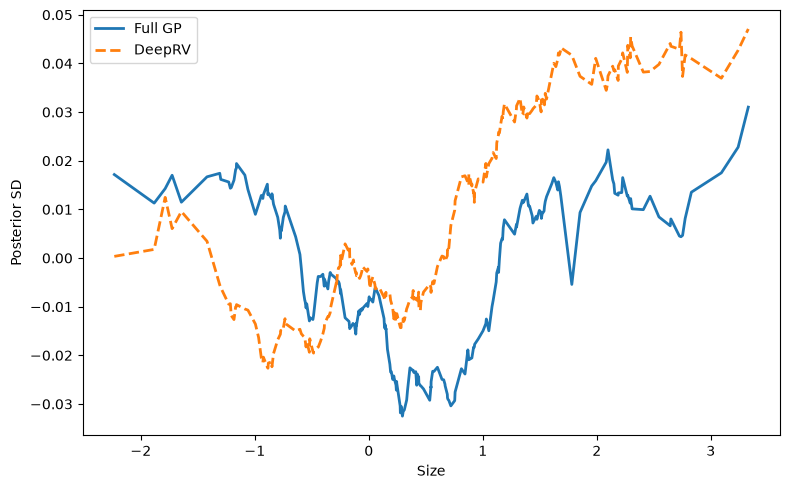

In [204]:
plot_posterior_means(
    s,
    samples_gp,
    samples_deeprv,
)

In [201]:
def plot_posterior_std(
    s,
    gp_samples,
    deeprv_samples,
):
    """
    Compare posterior standard deviation.
    """

    order = jnp.argsort(s.squeeze())

    gp_std = gp_samples["mu"].std(axis=0)[order]

    deeprv_std = deeprv_samples["mu"].std(axis=0)[order]

    s_sorted = s[order]

    plt.figure(figsize=(8, 5))

    plt.plot(
        s_sorted,
        gp_std,
        label="Full GP",
        linewidth=2,
    )

    plt.plot(
        s_sorted,
        deeprv_std,
        "--",
        label="DeepRV",
        linewidth=2,
    )

    plt.xlabel("Size")

    plt.ylabel("Posterior SD")

    plt.legend()

    plt.tight_layout()

    plt.show()

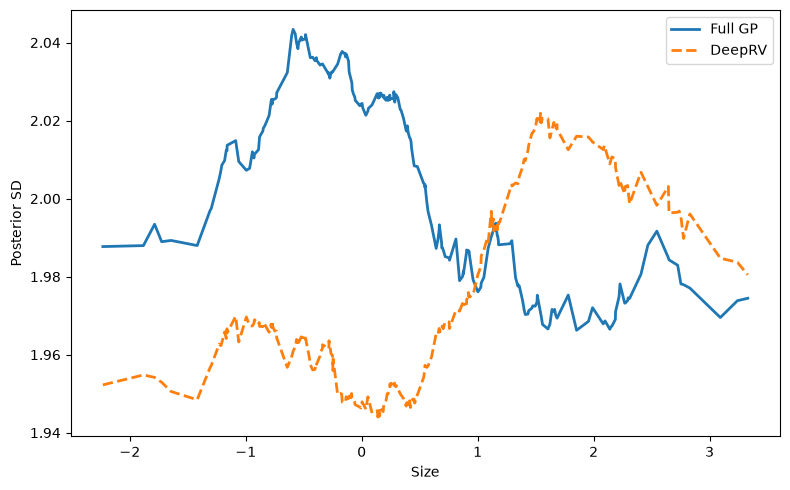

In [202]:
plot_posterior_std(
    s,
    samples_gp,
    samples_deeprv
)

## Extending DeepRV to Other Vital Rates

In this segment, we extend DeepRV to fit all other vital rates and then construct an IPM using the posterior samples.

For the monocarp species, a standard GLM specification for the vital rates is:

1. **Growth**
   $$
   z_1 \mid z \sim \mathcal{N}\!\bigl(f(z), \sigma\bigr)
   $$

2. **Flowering**
   $$
   \text{Flowering}(z) \sim \mathrm{Bernoulli}\!\bigl(\sigma(f(z))\bigr)
   $$

3. **Survival**
   $$
   \text{Survival}(z) \sim \mathrm{Bernoulli}\!\bigl(\sigma(f(z))\bigr)
   $$

4. **Seed production**
   $$
   \text{SeedProduction}(z) \sim \mathrm{Poisson}\!\bigl(\exp(f(z))\bigr)
   $$

5. **Recruit size** [Note that recruit size is independent of parent size.]
   $$
   z_1 \sim \mathcal{N}(\mu, \sigma)
   $$
   

Extending this to the GP framework, we have:

1. **Growth**
   $$
   f(z) \sim \mathcal{GP}(0, K)
   $$

2. **Flowering probability**
   $$
   p_f(z) = \sigma(f(z)), \qquad \text{Flowering}(z) \sim \mathrm{Bernoulli}(p_f(z))
   $$

3. **Survival probability**
   $$
   p_s(z) = \sigma(f(z)), \qquad \text{Survival}(z) \sim \mathrm{Bernoulli}(p_s(z))
   $$

4. **Seed production**
   $$
   \text{SeedProduction}(z) \sim \mathrm{Poisson}\!\bigl(\exp(f(z))\bigr)
   $$

5. **Recruit size**
   Since recruit size is independent of $z$, we use a fixed distribution, for example:
   $$
   z_1 \sim \Gamma(\alpha, \beta)
   $$